# Tox21 Modeling Notebook (Restructured)

## Run Order
1. Environment and imports
2. Data loading + EDA
3. RDKit feature engineering (descriptors + fingerprints)
4. Data cleaning (missing values, clipping, dedup)
5. Single-task baselines and tuned XGBoost
6. Evaluation and visualization (PR-AUC focused)
7. Multi-Task Learning (PyTorch prototype)
8. Molecule-level inference examples

## Notes
- Primary model-selection metric: **PR-AUC / Average Precision**.
- Keep endpoint-specific models as baseline; use MTL section to test shared representation learning across all endpoints.
- Run heavy tuning cells with `FAST_MODE=False` only after validating with `FAST_MODE=True`.

In [107]:
# Install deps (Windows-friendly)
# Notes: scikit-learn models are CPU-only; XGBoost can use GPU if CUDA is available.
!pip -q install --upgrade rdkit-pypi scikit-learn seaborn matplotlib imbalanced-learn xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import PandasTools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score, accuracy_score, roc_curve, auc)
from sklearn.feature_selection import SelectKBest, f_classif
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


In [2]:
df = pd.read_csv('tox21.csv')
print(f"dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")

dataset loaded with 7831 rows and 14 columns


In [3]:
print("="*80)
print("TOX21 DATASET OVERVIEW")
print("="*80)

print("\n📊 First 5 rows:")
display(df.head())

print("\n🔍 Dataset information:")
print(df.info())

print("\n📈 Descriptive statistics of targets:")
# Identify target columns
target_columns = ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 
                  'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 
                  'SR-HSE', 'SR-MMP', 'SR-p53']

# Convert targets to numeric
for col in target_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

display(df[target_columns].describe())

TOX21 DATASET OVERVIEW

📊 First 5 rows:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O



🔍 Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7265 non-null   float64
 1   NR-AR-LBD      6758 non-null   float64
 2   NR-AhR         6549 non-null   float64
 3   NR-Aromatase   5821 non-null   float64
 4   NR-ER          6193 non-null   float64
 5   NR-ER-LBD      6955 non-null   float64
 6   NR-PPAR-gamma  6450 non-null   float64
 7   SR-ARE         5832 non-null   float64
 8   SR-ATAD5       7072 non-null   float64
 9   SR-HSE         6467 non-null   float64
 10  SR-MMP         5810 non-null   float64
 11  SR-p53         6774 non-null   float64
 12  mol_id         7831 non-null   object 
 13  smiles         7831 non-null   object 
dtypes: float64(12), object(2)
memory usage: 856.6+ KB
None

📈 Descriptive statistics of targets:


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53
count,7265.000000,6758.000000,6549.000000,5821.000000,6193.000000,6955.000000,6450.000000,5832.000000,7072.000000,6467.000000,5810.000000,6774.000000
mean,0.042533,0.035070,0.117270,0.051538,0.128048,0.050324,0.028837,0.161523,0.037330,0.057523,0.158003,0.062445
std,0.201815,0.183969,0.321766,0.221110,0.334170,0.218627,0.167362,0.368044,0.189583,0.232857,0.364776,0.241979
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


1. EXPLORATORY DATA ANALYSIS (EDA)

🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS


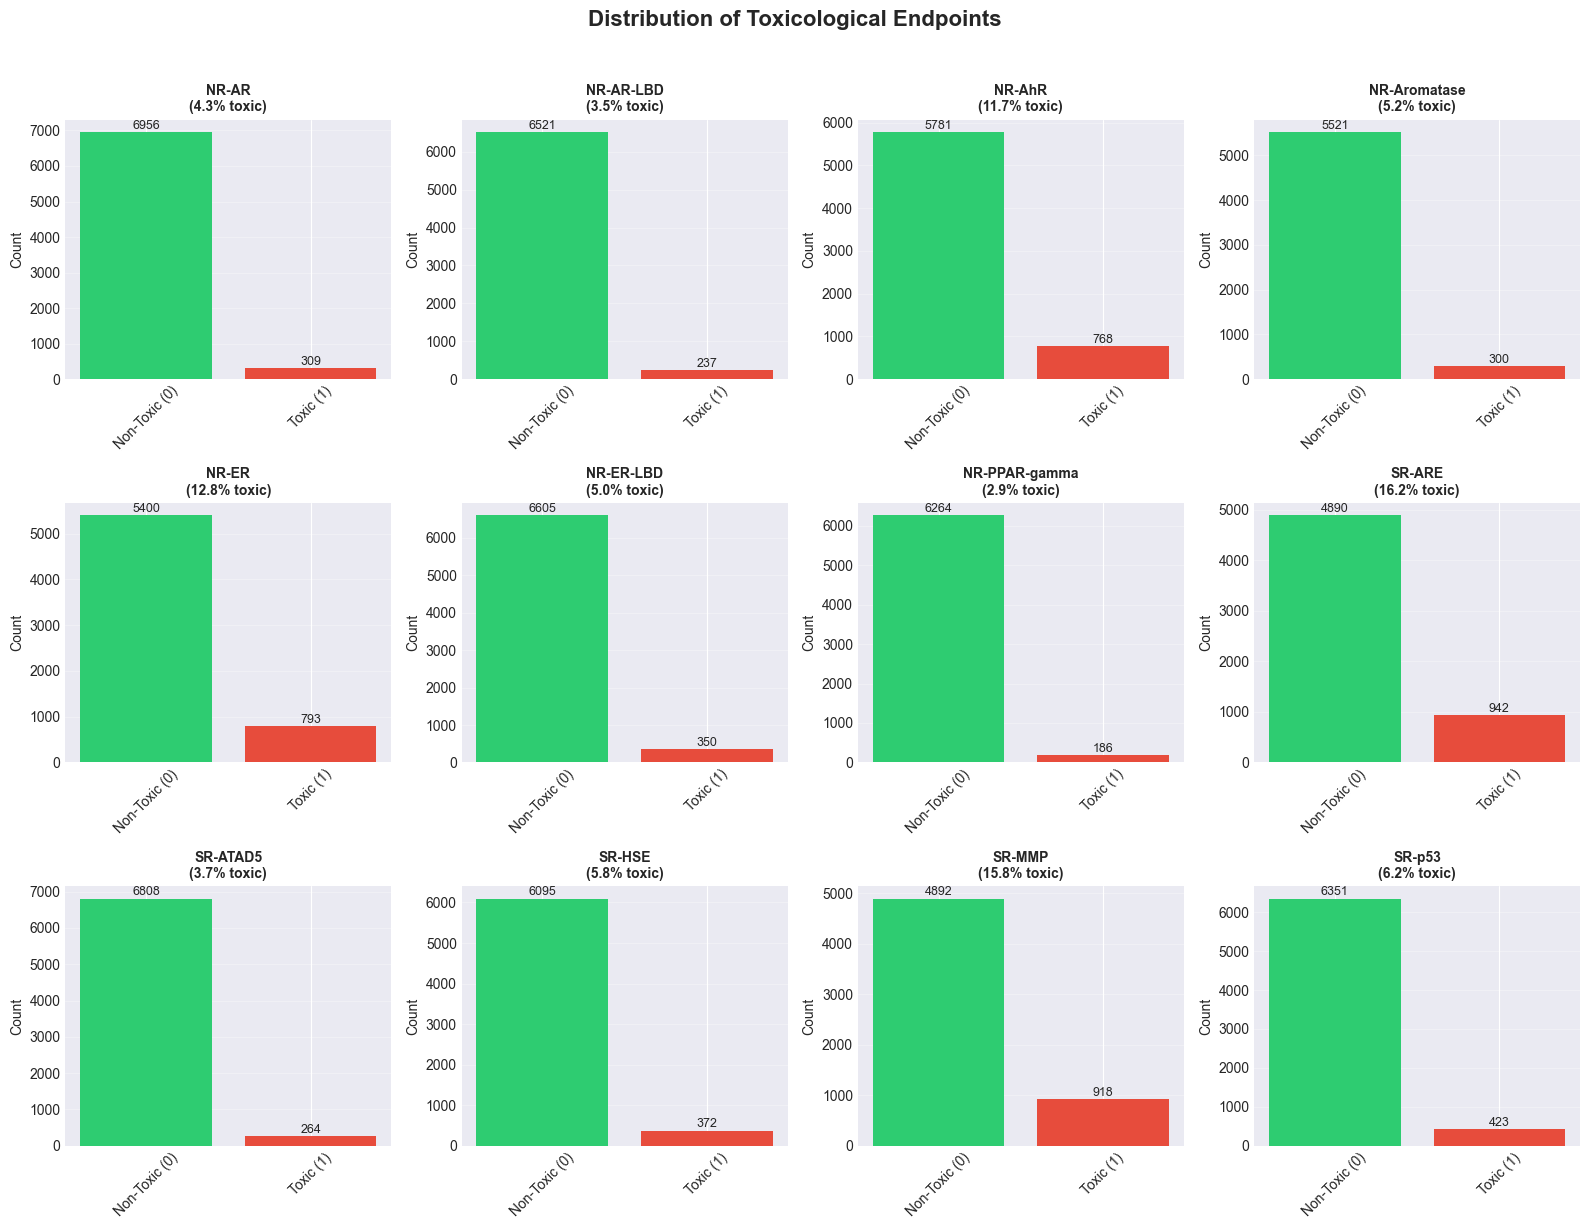

In [4]:
print("="*80)
print("1. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 1.1 Target distributions
print("\n🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_columns):
    ax = axes[idx]
    target_data = df[target].dropna()
    
    if len(target_data) > 0:
        # Count values
        counts = target_data.value_counts().sort_index()
        
        # Create plot
        bars = ax.bar(['Non-Toxic (0)', 'Toxic (1)'], 
                     [counts.get(0, 0), counts.get(1, 0)],
                     color=['#2ecc71', '#e74c3c'])
        
        # Add numbers
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                   f'{int(height)}', ha='center', va='bottom', fontsize=9)
        
        # Calculate percentage
        total = len(target_data)
        pos_rate = counts.get(1, 0) / total * 100
        
        ax.set_title(f'{target}\n({pos_rate:.1f}% toxic)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        # Add grid
        ax.grid(True, alpha=0.3, axis='y')
        
        # Remove spines
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(target, fontsize=10)

plt.suptitle('Distribution of Toxicological Endpoints', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

1. EXPLORATORY DATA ANALYSIS (EDA)

🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS


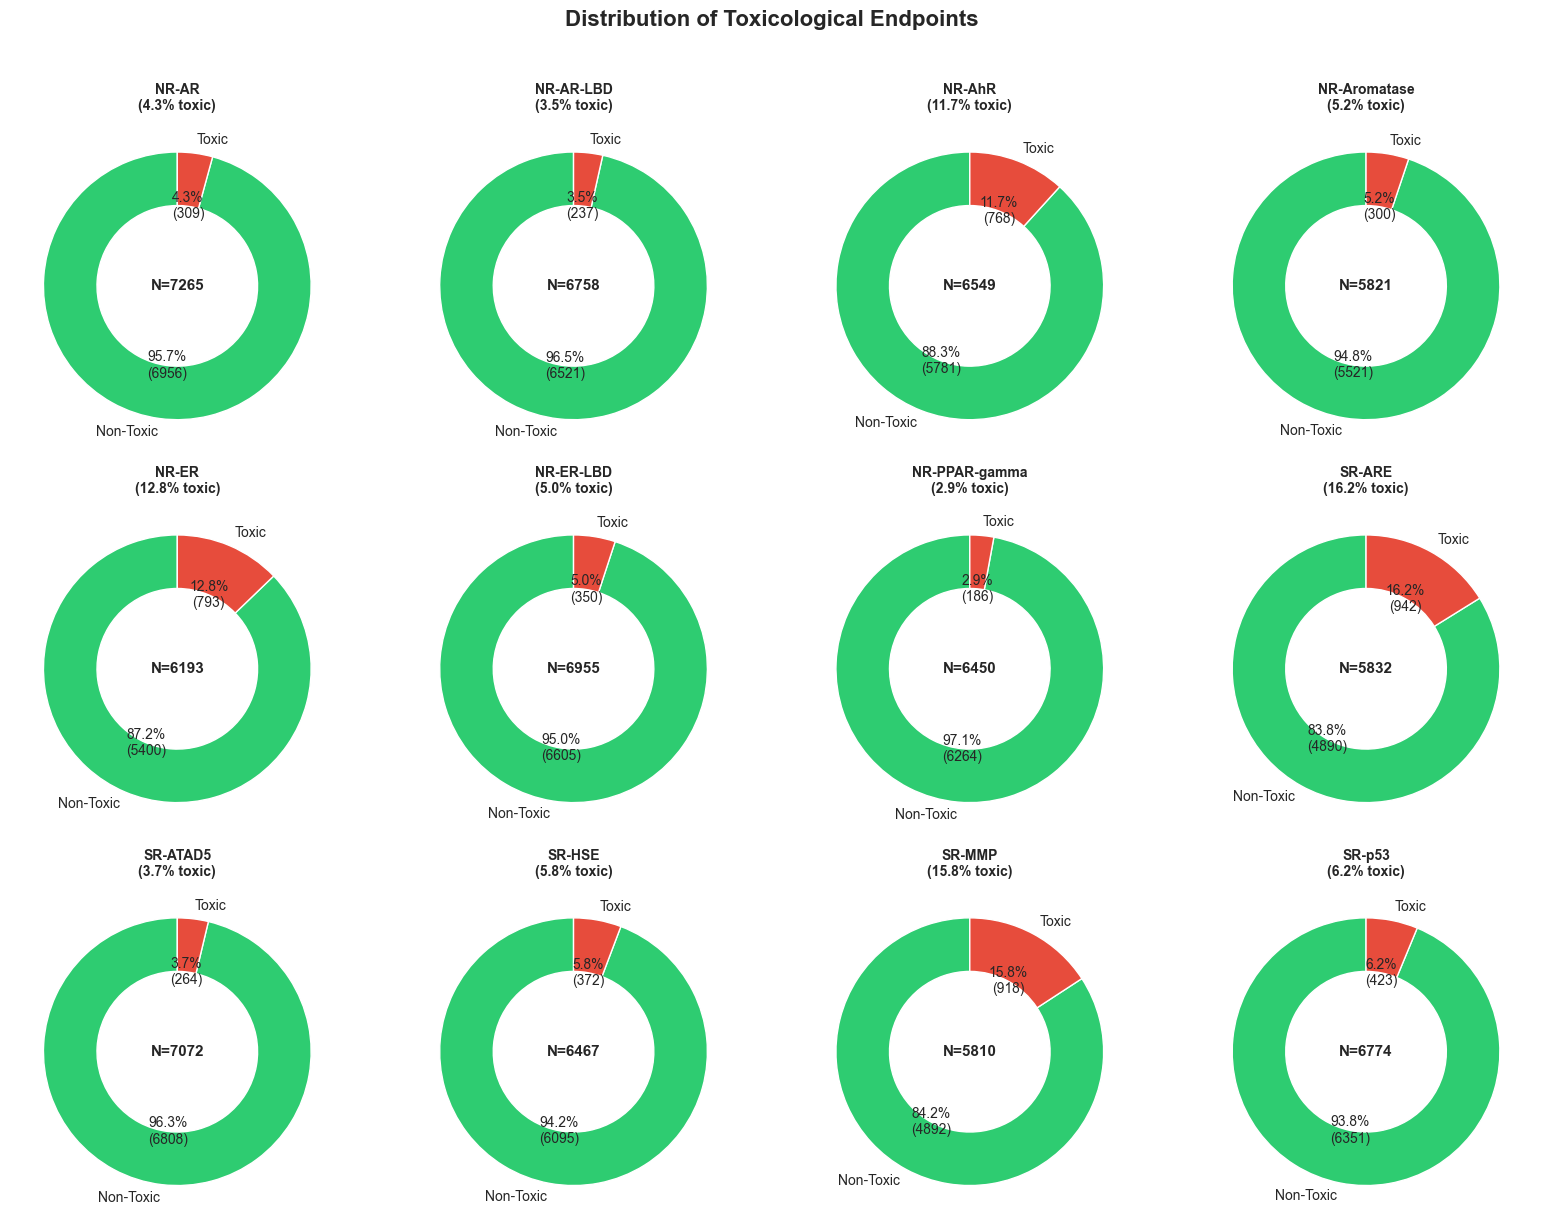

In [5]:
print("="*80)
print("1. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# 1.1 Target distributions
print("\n🎯 1.1 TOXICOLOGICAL TARGET DISTRIBUTIONS")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(target_columns):
    ax = axes[idx]
    target_data = df[target].dropna()

    if len(target_data) > 0:
        # Count values
        counts = target_data.value_counts().sort_index()

        non_toxic = counts.get(0, 0)
        toxic = counts.get(1, 0)
        total = non_toxic + toxic

        # Donut chart
        wedges, texts, autotexts = ax.pie(
            [non_toxic, toxic],
            labels=['Non-Toxic', 'Toxic'],
            colors=['#2ecc71', '#e74c3c'],
            autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct*total/100))})',
            startangle=90,
            wedgeprops=dict(width=0.4, edgecolor='white')
        )

        # Center text
        ax.text(
            0, 0,
            f'N={total}',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold'
        )

        # Toxic percentage
        pos_rate = toxic / total * 100 if total > 0 else 0

        ax.set_title(
            f'{target}\n({pos_rate:.1f}% toxic)',
            fontsize=10,
            fontweight='bold'
        )

    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(target, fontsize=10)

plt.suptitle(
    'Distribution of Toxicological Endpoints',
    fontsize=16,
    y=1.02,
    fontweight='bold'
)
plt.tight_layout()
plt.show()


⚠️ 1.2 MISSING VALUES ANALYSIS

Total cells with missing values: 16,026
Total missing percentage: 14.62%

Top 20 columns with most missing values:


,Column,Missing Values,Percentage (%)
10,SR-MMP,2021,25.807687
3,NR-Aromatase,2010,25.667220
7,SR-ARE,1999,25.526753
4,NR-ER,1638,20.916869
6,NR-PPAR-gamma,1381,17.635040
9,SR-HSE,1364,17.417954
2,NR-AhR,1282,16.370834
1,NR-AR-LBD,1073,13.701954
11,SR-p53,1057,13.497638
5,NR-ER-LBD,876,11.186311


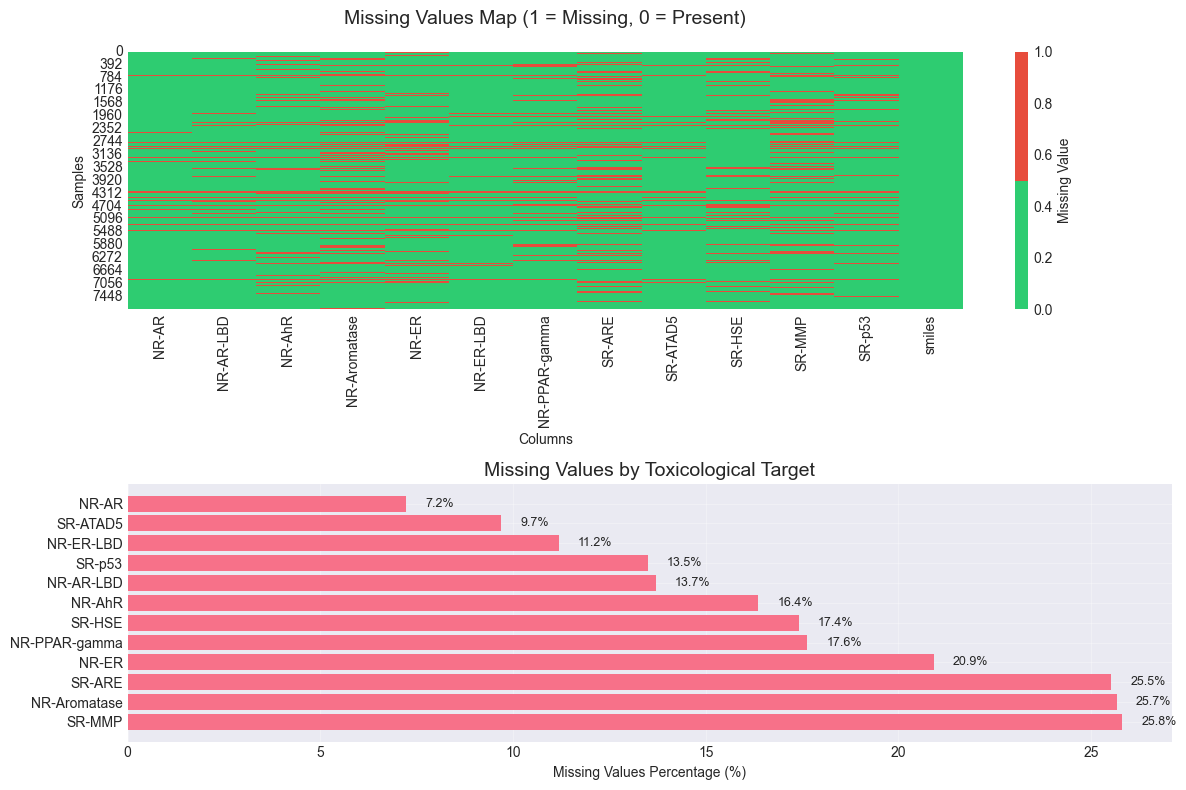

In [112]:
# 1.2 Missing values analysis
print("\n⚠️ 1.2 MISSING VALUES ANALYSIS")

# Calculate missing values per column
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).values
})

print(f"\nTotal cells with missing values: {df.isnull().sum().sum():,}")
print(f"Total missing percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")

# Top 20 columns with most missing values
missing_data_sorted = missing_data.sort_values('Percentage (%)', ascending=False)
print("\nTop 20 columns with most missing values:")
display(missing_data_sorted.head(20))

# Missing values visualization
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)

# Missing values heatmap (only first 50 columns for visualization)
cols_to_show = target_columns + ['smiles']  # Show only targets and smiles
missing_matrix = df[cols_to_show].isnull()

sns.heatmap(missing_matrix, cbar_kws={'label': 'Missing Value'}, 
            cmap=['#2ecc71', '#e74c3c'])
plt.title('Missing Values Map (1 = Missing, 0 = Present)', fontsize=14, pad=20)
plt.xlabel('Columns')
plt.ylabel('Samples')

plt.subplot(2, 1, 2)
# Missing percentage per target
target_missing = missing_data_sorted[missing_data_sorted['Column'].isin(target_columns)]
bars = plt.barh(target_missing['Column'], target_missing['Percentage (%)'])
plt.xlabel('Missing Values Percentage (%)')
plt.title('Missing Values by Toxicological Target', fontsize=14)
plt.grid(True, alpha=0.3)

# Add values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


🔗 1.3 CORRELATION MATRIX BETWEEN TARGETS


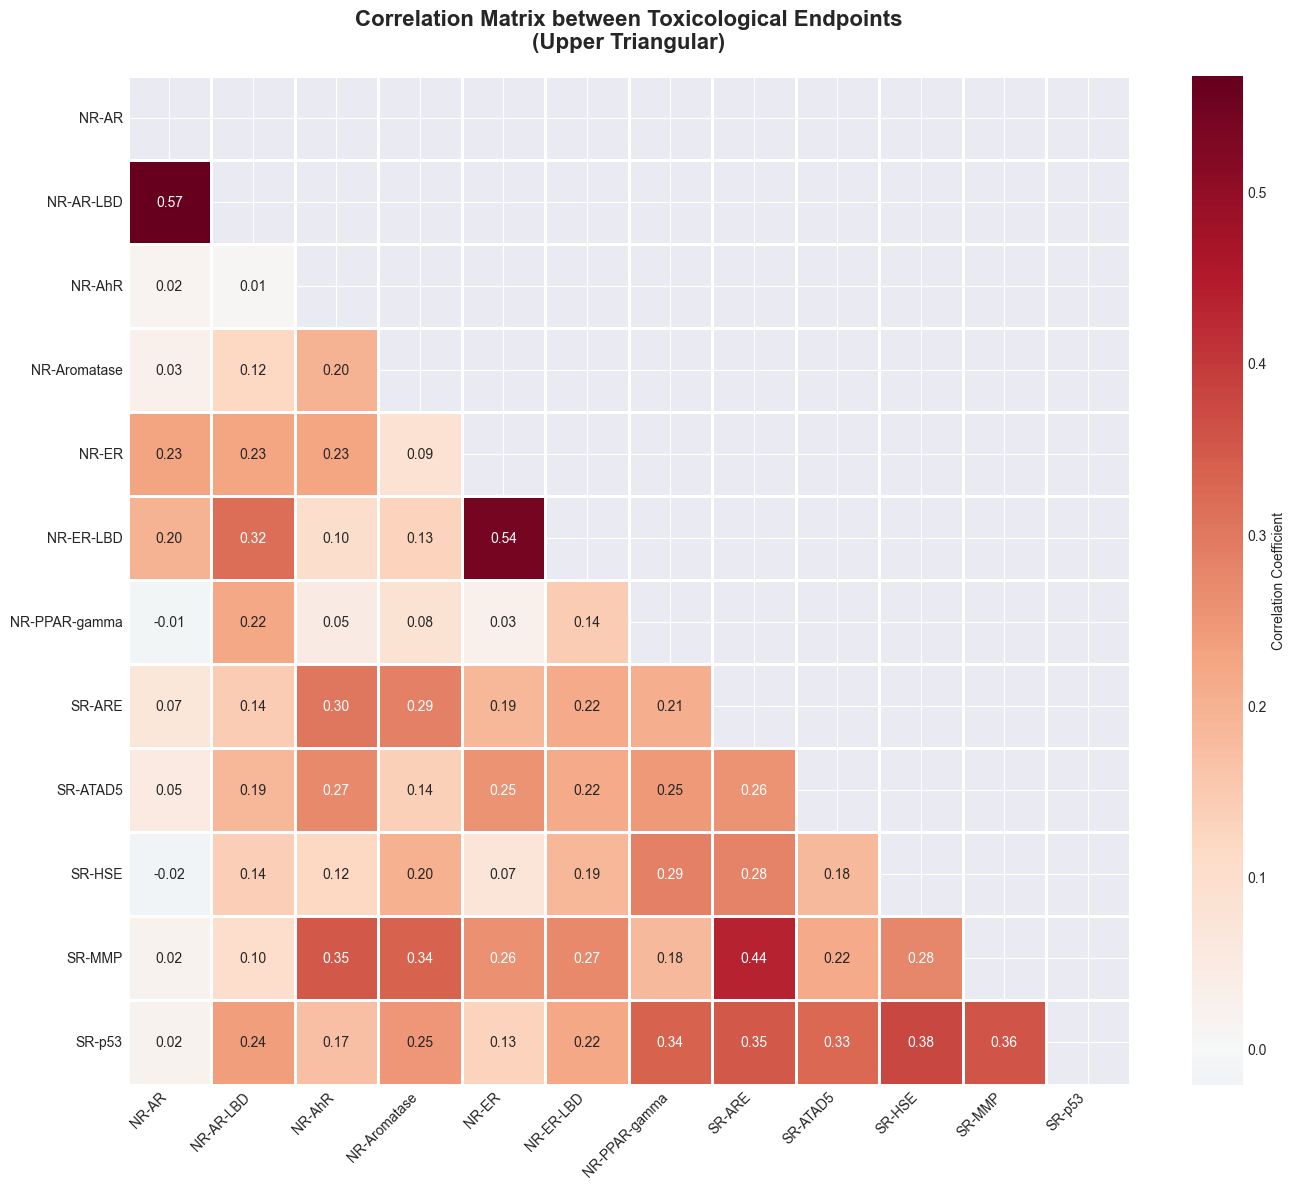


🔍 Strong correlations (|r| > 0.5):


,Target 1,Target 2,Correlation
0,NR-AR,NR-AR-LBD,0.567408
1,NR-ER,NR-ER-LBD,0.541272


In [113]:
# 1.3 Correlation matrix between targets
print("\n🔗 1.3 CORRELATION MATRIX BETWEEN TARGETS")

# Calculate correlation
correlation_matrix = df[target_columns].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r',
           center=0, fmt='.2f', linewidths=1, linecolor='white',
           cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix between Toxicological Endpoints\n(Upper Triangular)', 
          fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identify strong correlations
print("\n🔍 Strong correlations (|r| > 0.5):")
strong_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5 and not np.isnan(corr):
            strong_correlations.append({
                'Target 1': correlation_matrix.columns[i],
                'Target 2': correlation_matrix.columns[j],
                'Correlation': corr
            })

if strong_correlations:
    strong_corr_df = pd.DataFrame(strong_correlations)
    display(strong_corr_df.sort_values('Correlation', ascending=False))
else:
    print("No strong correlations found (|r| > 0.5)")

2. CHEMICAL DATA ANALYSIS WITH RDKIT

🧪 2.1 MOLECULAR PROPERTIES EXTRACTION
Converting SMILES to RDKit Molecule objects...


[14:01:37] WARNING: not removing hydrogen atom without neighbors


Converted 1000 molecules from 1000 samples

🔬 Example molecular structures:


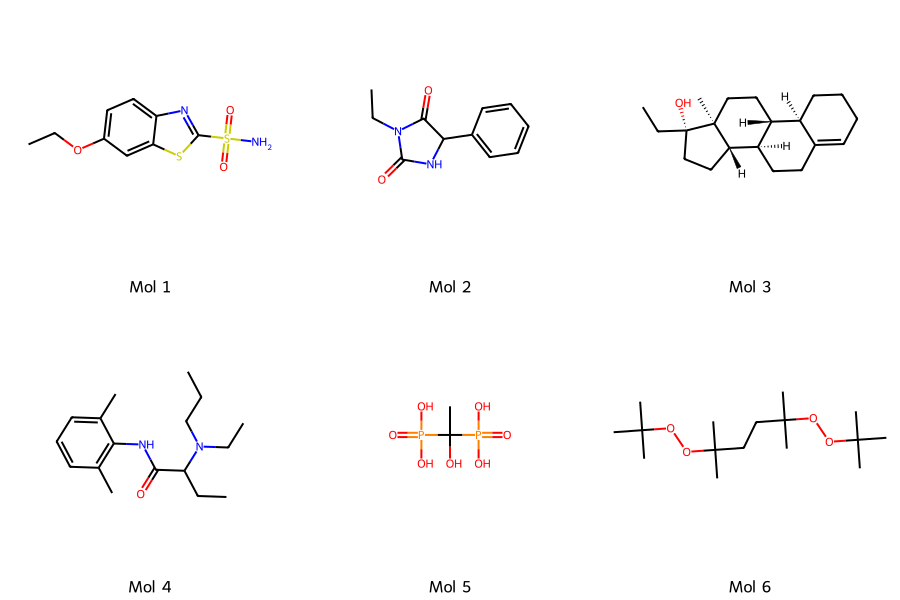

In [114]:
# 2. CHEMICAL DATA ANALYSIS WITH RDKIT
print("="*80)
print("2. CHEMICAL DATA ANALYSIS WITH RDKIT")
print("="*80)

print("\n🧪 2.1 MOLECULAR PROPERTIES EXTRACTION")
# Add RDKit Molecule column
print("Converting SMILES to RDKit Molecule objects...")

def safe_smiles_to_mol(smiles):
    """Convert SMILES to RDKit molecule with error handling"""
    if pd.isna(smiles):
        return None
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            # Try without sanitization
            mol = Chem.MolFromSmiles(str(smiles), sanitize=False)
        return mol
    except:
        return None

# Convert first 1000 molecules for demonstration (for performance)
sample_size = min(1000, len(df))
df_sample = df.iloc[:sample_size].copy()
df_sample['Molecule'] = df_sample['smiles'].apply(safe_smiles_to_mol)

print(f"Converted {df_sample['Molecule'].notna().sum()} molecules from {sample_size} samples")

# Display some molecules
print("\n🔬 Example molecular structures:")
valid_mols = df_sample[df_sample['Molecule'].notna()].head(6)['Molecule'].tolist()
img = Draw.MolsToGridImage(valid_mols, molsPerRow=3, subImgSize=(300, 300),
                          legends=[f"Mol {i+1}" for i in range(len(valid_mols))])
display(img)

In [115]:
# 2.2 Feature engineering (fingerprints + descriptors)
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors

print("\n🧬 2.2 COMPUTE FEATURES FOR MODELING")

# De-duplicate by SMILES (common in curated chem datasets)
df_feat = df.copy()
n_before = len(df_feat)
df_feat = df_feat.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
print(f"Removed duplicates by SMILES: {n_before - len(df_feat):,}")

# Build molecules for the full dataset (drop invalid SMILES)
df_feat["Molecule"] = df_feat["smiles"].apply(safe_smiles_to_mol)
df_feat = df_feat[df_feat["Molecule"].notna()].reset_index(drop=True)
print(f"Valid molecules: {len(df_feat):,} / {len(df):,}")

# A small set of interpretable descriptors + ECFP (Morgan) fingerprint
DESCRIPTOR_FUNCS = {
    "MolWt": Descriptors.MolWt,
    "MolLogP": Descriptors.MolLogP,
    "TPSA": Descriptors.TPSA,
    "NumHDonors": Descriptors.NumHDonors,
    "NumHAcceptors": Descriptors.NumHAcceptors,
    "NumRotatableBonds": Descriptors.NumRotatableBonds,
    "RingCount": rdMolDescriptors.CalcNumRings,
    "HeavyAtomCount": Descriptors.HeavyAtomCount,
}

def mol_to_descriptors(mol):
    out = {}
    for name, fn in DESCRIPTOR_FUNCS.items():
        try:
            out[name] = float(fn(mol))
        except Exception:
            out[name] = np.nan
    return out

def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    arr = np.zeros((n_bits,), dtype=np.int8)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Compute descriptor matrix (raw)
desc_df = pd.DataFrame([mol_to_descriptors(m) for m in df_feat["Molecule"]]).astype(float)
print("Descriptor matrix:", desc_df.shape)

# Compute fingerprint matrix
fp_bits = 2048
fps = np.vstack([mol_to_morgan_fp(m, radius=2, n_bits=fp_bits) for m in df_feat["Molecule"]])
print("Fingerprint matrix:", fps.shape)

# Placeholder combine (will be replaced after outlier handling/imputation in next cell)
X_all = np.hstack([fps, desc_df.to_numpy()]).astype(np.float32)
feature_names = [f"FP_{i}" for i in range(fp_bits)] + list(desc_df.columns)
print("Initial feature matrix:", X_all.shape)


🧬 2.2 COMPUTE FEATURES FOR MODELING
Removed duplicates by SMILES: 0


[14:01:38] WARNING: not removing hydrogen atom without neighbors


Valid molecules: 7,831 / 7,831
Descriptor matrix: (7831, 8)
Fingerprint matrix: (7831, 2048)
Initial feature matrix: (7831, 2056)


2.3 MISSING VALUES + OUTLIERS (DESCRIPTORS)

Missing label rate per endpoint (%):


,missing_%
SR-MMP,25.807687
NR-Aromatase,25.667220
SR-ARE,25.526753
NR-ER,20.916869
NR-PPAR-gamma,17.635040
SR-HSE,17.417954
NR-AhR,16.370834
NR-AR-LBD,13.701954
SR-p53,13.497638
NR-ER-LBD,11.186311



Descriptor missingness (%):


,missing_%
MolWt,0.0
MolLogP,0.0
TPSA,0.0
NumHDonors,0.0
NumHAcceptors,0.0
NumRotatableBonds,0.0
RingCount,0.0
HeavyAtomCount,0.0



Outlier clipping summary (top descriptors):


,descriptor,lower,upper,n_clipped
2,TPSA,-49.862500,153.237500,389
5,NumRotatableBonds,-6.500000,13.500000,326
4,NumHAcceptors,-2.500000,9.500000,320
0,MolWt,-101.531000,609.789000,297
7,HeavyAtomCount,-7.000000,41.000000,284
1,MolLogP,-2.608675,7.409125,270
3,NumHDonors,-3.000000,5.000000,196
6,RingCount,-2.000000,6.000000,93


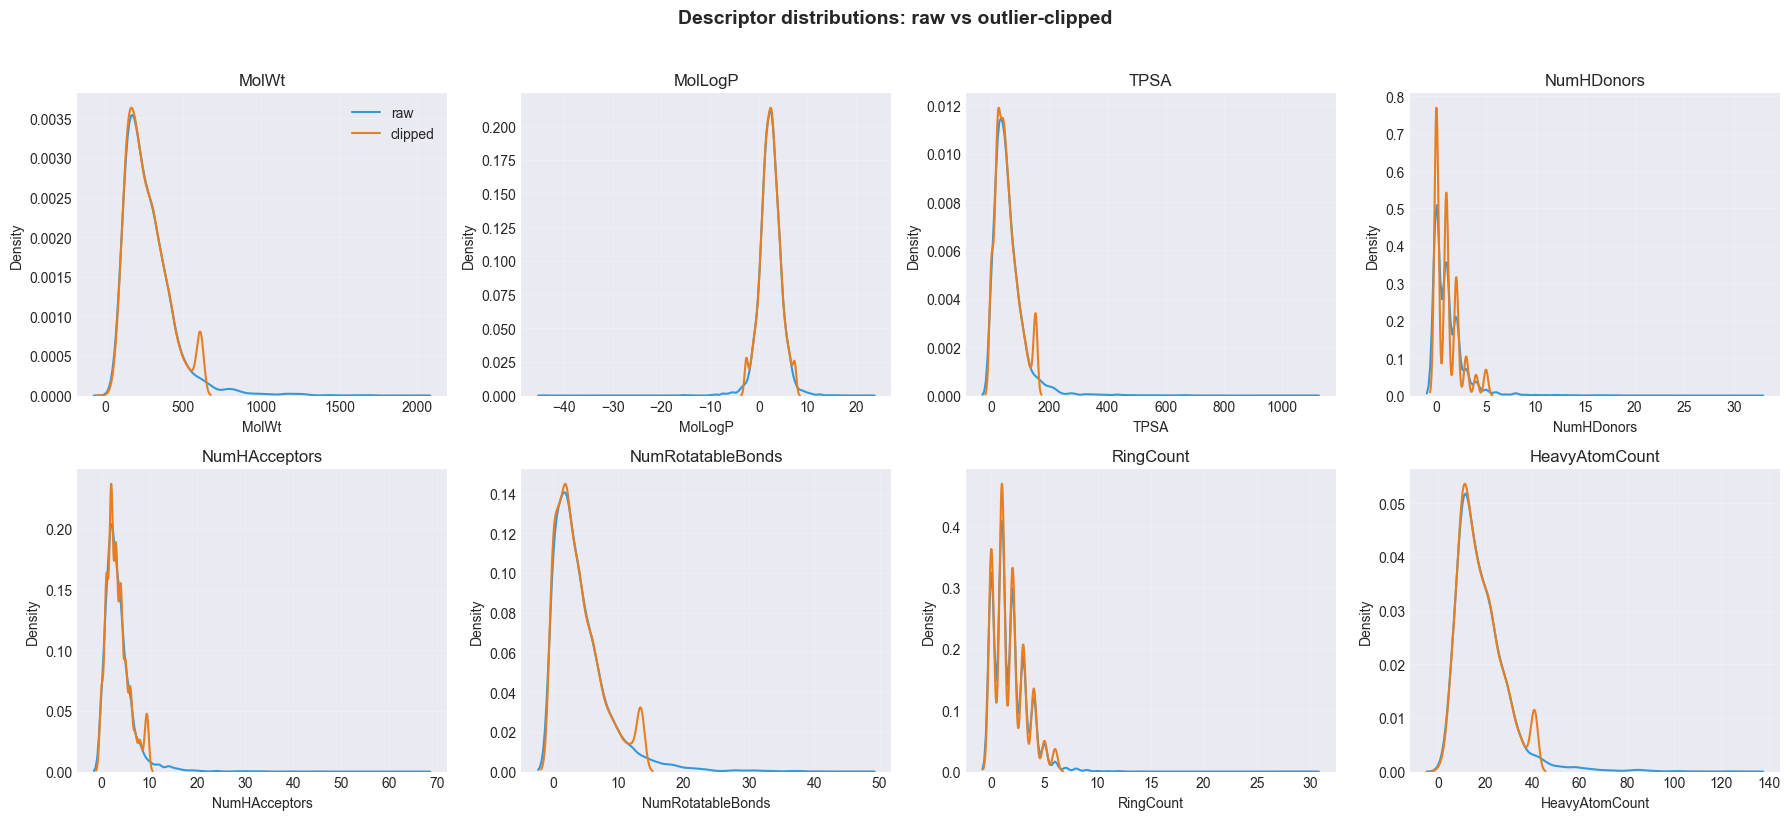

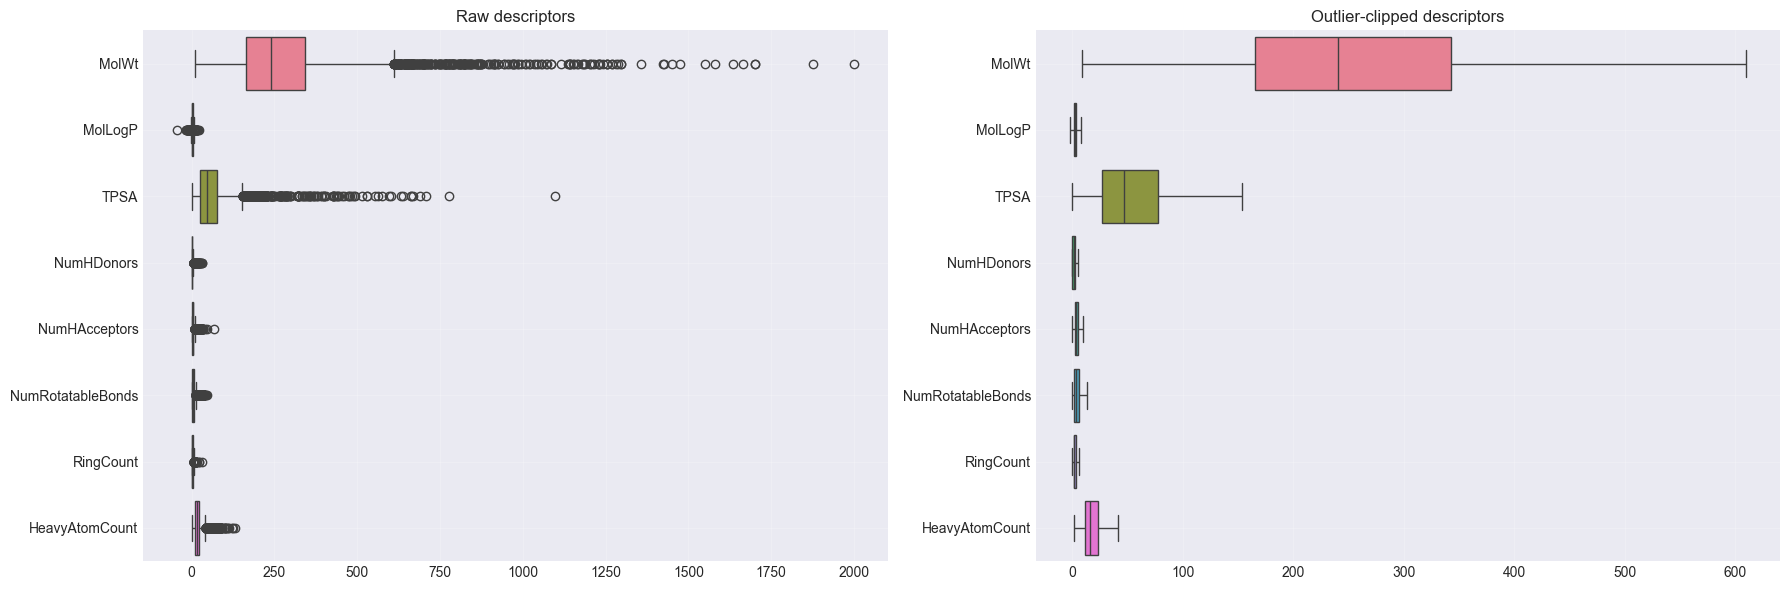


Final modeling matrix after clipping+imputation: (7831, 2056)


In [116]:
# 2.3 Advanced missing-value handling + outliers (descriptors)
print("="*80)
print("2.3 MISSING VALUES + OUTLIERS (DESCRIPTORS)")
print("="*80)

# Missingness overview (targets + smiles) before filtering per-task
missing_targets = (df_feat[target_columns].isna().mean() * 100).sort_values(ascending=False)
print("\nMissing label rate per endpoint (%):")
display(missing_targets.to_frame("missing_%"))

print("\nDescriptor missingness (%):")
display((desc_df.isna().mean() * 100).to_frame("missing_%"))

# Outlier handling on continuous descriptors (IQR clipping / winsorization)
desc_df_raw = desc_df.copy()
clip_report = []
desc_df_clipped = desc_df.copy()

for col in desc_df.columns:
    s = desc_df[col]
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_clipped = int(((s < lower) | (s > upper)).sum())
    clip_report.append({"descriptor": col, "lower": float(lower), "upper": float(upper), "n_clipped": n_clipped})
    desc_df_clipped[col] = s.clip(lower, upper)

clip_report_df = pd.DataFrame(clip_report).sort_values("n_clipped", ascending=False)
print("\nOutlier clipping summary (top descriptors):")
display(clip_report_df)

# Visualize descriptor distributions (raw vs clipped)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(desc_df.columns):
    ax = axes[i]
    sns.kdeplot(desc_df_raw[col], ax=ax, label="raw", color="#3498db")
    sns.kdeplot(desc_df_clipped[col], ax=ax, label="clipped", color="#e67e22")
    ax.set_title(col)
    ax.grid(True, alpha=0.2)
    if i == 0:
        ax.legend()
plt.suptitle("Descriptor distributions: raw vs outlier-clipped", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Show before/after boxplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)
sns.boxplot(data=desc_df_raw, orient="h", ax=axes[0])
axes[0].set_title("Raw descriptors")
sns.boxplot(data=desc_df_clipped, orient="h", ax=axes[1])
axes[1].set_title("Outlier-clipped descriptors")
for ax in axes:
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Advanced imputation: median for descriptors only (fingerprints are already 0/1)
from sklearn.impute import SimpleImputer

desc_imputer = SimpleImputer(strategy="median")
X_desc_imp = desc_imputer.fit_transform(desc_df_clipped)
X_model = np.hstack([fps, X_desc_imp]).astype(np.float32)

# Refresh combined features after cleaning
X_all = X_model
feature_names = [f"FP_{i}" for i in range(fp_bits)] + list(desc_df.columns)
print("\nFinal modeling matrix after clipping+imputation:", X_model.shape)

2.4 RDKIT VISUAL EDA
Primary endpoint for deep-dive: NR-AR
Samples with label for NR-AR: 7,265


,count
NR-AR,
0,6956
1,309


,%
NR-AR,
0,95.746731
1,4.253269


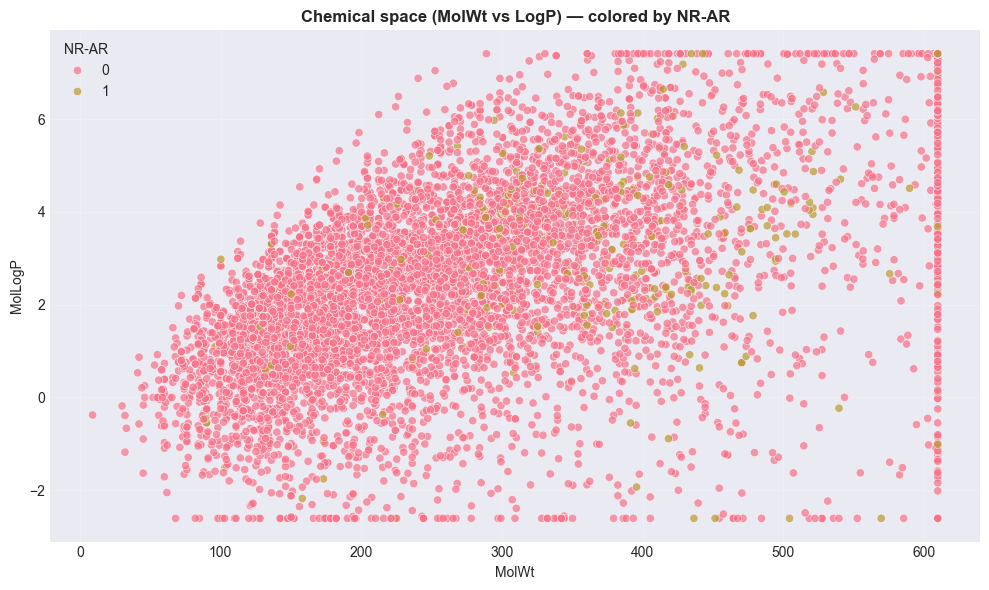

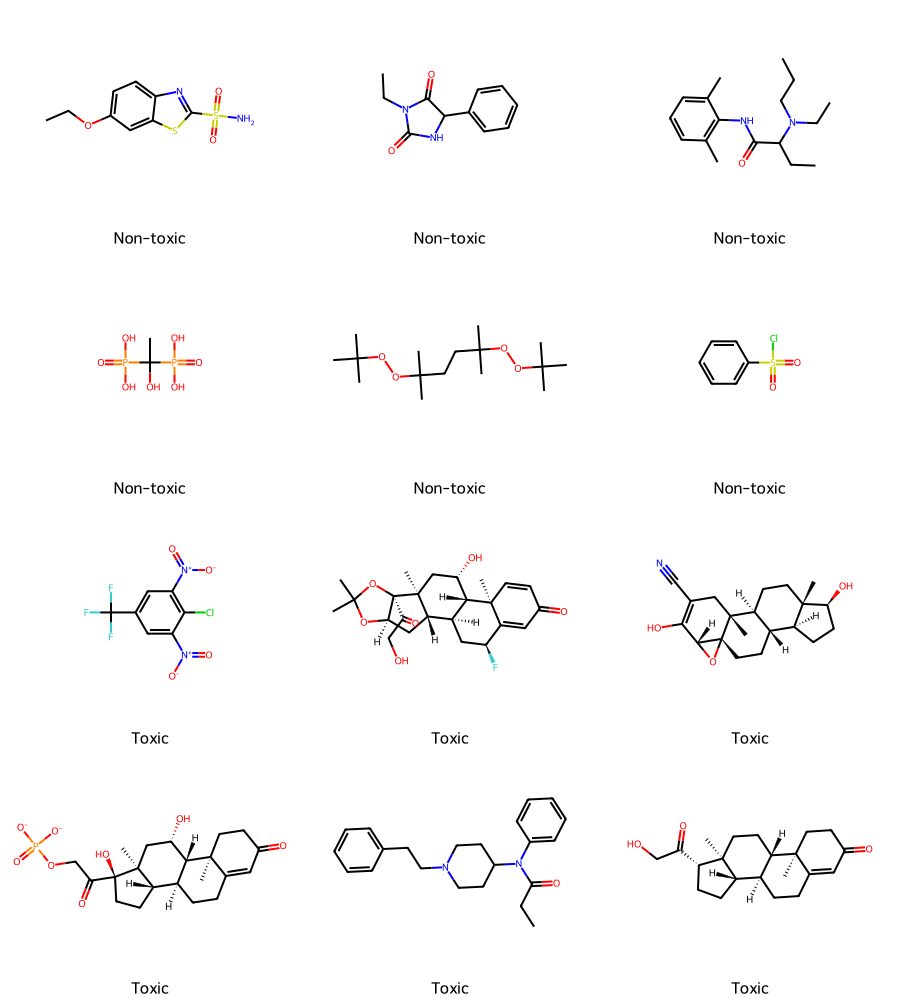

In [117]:
# 2.4 RDKit visual EDA (properties + example molecules)
print("="*80)
print("2.4 RDKIT VISUAL EDA")
print("="*80)

# Build a plotting-friendly table with aligned descriptor columns
df_feat_desc = pd.concat([df_feat.reset_index(drop=True), desc_df_clipped.reset_index(drop=True)], axis=1)

# Pick a "primary" endpoint for deeper modeling/plots (most labels, both classes)
candidates = []
for t in target_columns:
    y = df_feat_desc[t].dropna()
    if y.nunique() >= 2:
        candidates.append((t, int(y.shape[0])))
primary_target = max(candidates, key=lambda x: x[1])[0] if candidates else target_columns[0]
print(f"Primary endpoint for deep-dive: {primary_target}")

df_task = df_feat_desc[df_feat_desc[primary_target].notna()].copy()
df_task[primary_target] = df_task[primary_target].astype(int)
print(f"Samples with label for {primary_target}: {len(df_task):,}")
display(df_task[primary_target].value_counts().rename("count").to_frame())
display((df_task[primary_target].value_counts(normalize=True)*100).rename("%" ).to_frame())

# Scatter: MolWt vs MolLogP colored by label
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_task, x="MolWt", y="MolLogP", hue=primary_target, alpha=0.7)
plt.title(f"Chemical space (MolWt vs LogP) — colored by {primary_target}", fontweight="bold")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Example molecules: toxic vs non-toxic
n_show = 6
tox_mols = df_task[df_task[primary_target] == 1].head(n_show)["Molecule"].tolist()
nontox_mols = df_task[df_task[primary_target] == 0].head(n_show)["Molecule"].tolist()
mols = nontox_mols + tox_mols
legends = ["Non-toxic"] * len(nontox_mols) + ["Toxic"] * len(tox_mols)
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 250), legends=legends)
display(img)

2.5 FINGERPRINT EMBEDDING (2D)
Embedding subset size: 2000, PCA comps: 50, t-SNE perplexity: 30


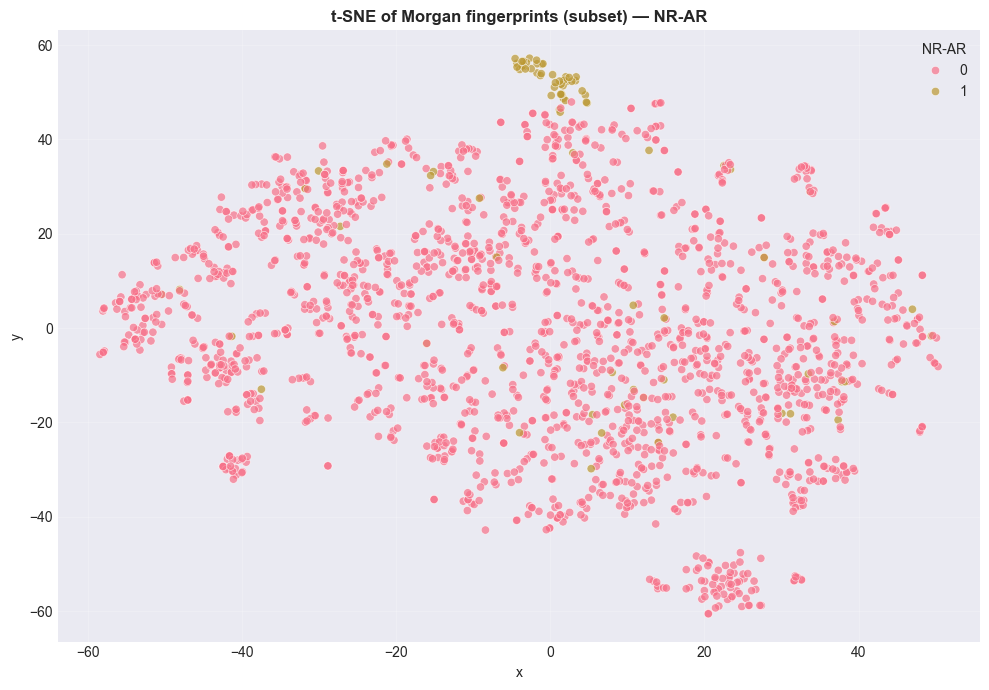

In [118]:
# 2.5 Fingerprint embedding (2D) for visualization
print("="*80)
print("2.5 FINGERPRINT EMBEDDING (2D)")
print("="*80)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Use a subset for speed
max_points = 2000
rng = np.random.RandomState(42)
idx = rng.choice(len(df_task), size=min(max_points, len(df_task)), replace=False)
X_fp_task = fps[df_task.index.values][:, :fp_bits]  # align to df_task via original indices
X_fp_sub = X_fp_task[idx].astype(np.float32)
y_sub = df_task.iloc[idx][primary_target].values

n_samples = X_fp_sub.shape[0]
n_pca = int(min(50, X_fp_sub.shape[1], max(2, n_samples - 1)))
perplexity = int(min(30, max(5, (n_samples - 1) // 3)))
print(f"Embedding subset size: {n_samples}, PCA comps: {n_pca}, t-SNE perplexity: {perplexity}")

# PCA -> t-SNE (more stable/faster)
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_fp_sub)
X_2d = TSNE(n_components=2, perplexity=perplexity, learning_rate="auto", init="pca", random_state=42).fit_transform(X_pca)

emb_df = pd.DataFrame({"x": X_2d[:, 0], "y": X_2d[:, 1], primary_target: y_sub})
plt.figure(figsize=(10, 7))
sns.scatterplot(data=emb_df, x="x", y="y", hue=primary_target, alpha=0.7)
plt.title(f"t-SNE of Morgan fingerprints (subset) — {primary_target}", fontweight="bold")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [120]:
# =============================================================================
# GPU XGBoost Baseline Modeling (one model per endpoint)
# =============================================================================

print("="*80)
print("3. GPU XGBOOST BASELINE MODELING")
print("="*80)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

def train_eval_single_task_xgb_gpu(
    target,
    random_state=42,
    test_size=0.2
):

    # Target
    y = df_feat[target]

    # Remove missing labels
    mask = y.notna()

    X = X_model[mask.values]
    y = y[mask].astype(int)

    # Skip if only one class
    if y.nunique() < 2:
        return None

    # Train / Test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Handle imbalance
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    scale_pos_weight = neg / pos if pos > 0 else 1

    # GPU XGBoost
    model = XGBClassifier(
        objective="binary:logistic",

        # GPU
        tree_method="hist",
        device="cuda",

        # Speed
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,

        # Regularization
        subsample=0.8,
        colsample_bytree=0.8,

        # Imbalance handling
        scale_pos_weight=scale_pos_weight,

        # Misc
        eval_metric="auc",
        random_state=random_state,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Predict probabilities
    proba = model.predict_proba(X_test)[:, 1]

    # Binary predictions
    pred = (proba >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y_test, proba)
    acc = accuracy_score(y_test, pred)

    return {
        "target": target,
        "n_samples": int(len(y)),
        "pos_rate_%": float(y.mean() * 100.0),
        "roc_auc": float(auc),
        "accuracy": float(acc),
    }


# =============================================================================
# Train all endpoints
# =============================================================================

results = []

for t in target_columns:

    print(f"Training GPU XGBoost for: {t}")

    r = train_eval_single_task_xgb_gpu(t)

    if r is not None:
        results.append(r)
    else:
        print(f"Skipping {t}: only one class present after filtering")


# =============================================================================
# Results dataframe
# =============================================================================

results_df = (
    pd.DataFrame(results)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

print("\n📌 GPU XGBoost baseline results:")
display(results_df)

print("\nSummary:")
print(f"Mean ROC-AUC: {results_df['roc_auc'].mean():.3f}")
print(f"Median ROC-AUC: {results_df['roc_auc'].median():.3f}")

3. GPU XGBOOST BASELINE MODELING
Training GPU XGBoost for: NR-AR
Training GPU XGBoost for: NR-AR-LBD
Training GPU XGBoost for: NR-AhR
Training GPU XGBoost for: NR-Aromatase
Training GPU XGBoost for: NR-ER
Training GPU XGBoost for: NR-ER-LBD
Training GPU XGBoost for: NR-PPAR-gamma
Training GPU XGBoost for: SR-ARE
Training GPU XGBoost for: SR-ATAD5
Training GPU XGBoost for: SR-HSE
Training GPU XGBoost for: SR-MMP
Training GPU XGBoost for: SR-p53

📌 GPU XGBoost baseline results:


,target,n_samples,pos_rate_%,roc_auc,accuracy
0,SR-MMP,5810,15.800344,0.930148,0.894148
1,NR-AhR,6549,11.726981,0.895660,0.886260
2,SR-p53,6774,6.244464,0.887087,0.909225
3,SR-ATAD5,7072,3.733032,0.876375,0.951943
4,NR-Aromatase,5821,5.153754,0.869985,0.945064
5,SR-ARE,5832,16.152263,0.841012,0.822622
6,NR-PPAR-gamma,6450,2.883721,0.840081,0.957364
7,NR-ER-LBD,6955,5.032351,0.801146,0.947520
8,SR-HSE,6467,5.752281,0.798278,0.922720
9,NR-AR-LBD,6758,3.506955,0.785375,0.973373



Summary:
Mean ROC-AUC: 0.831
Median ROC-AUC: 0.841


4. PERFORMANCE VISUALIZATION


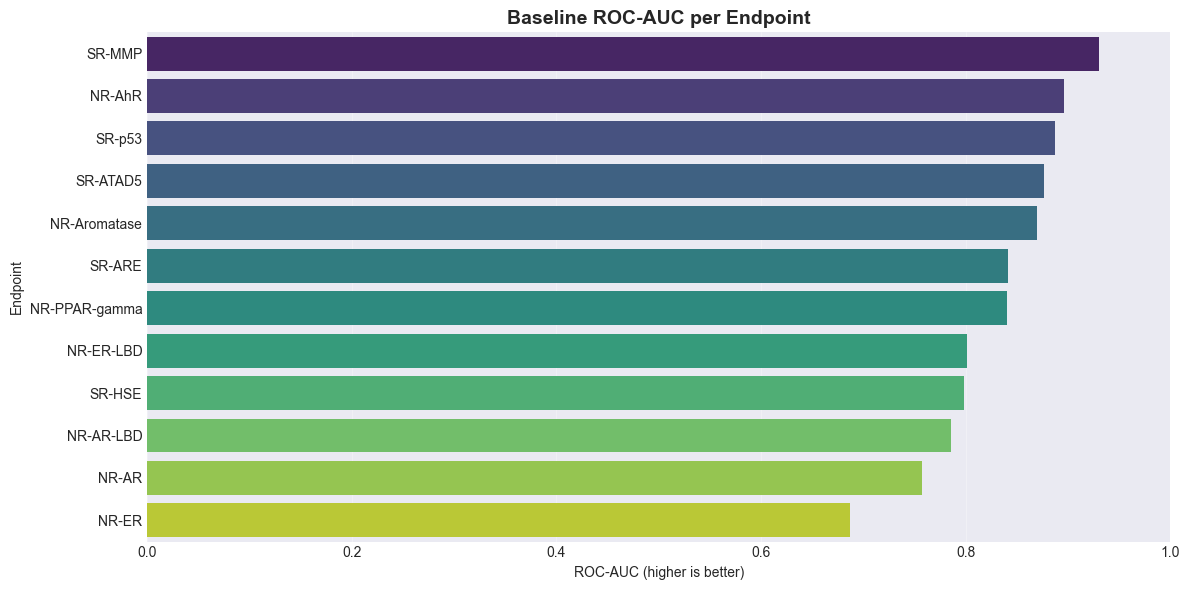

Best endpoint: SR-MMP (ROC-AUC=0.930, n=5810)
Worst endpoint: NR-ER (ROC-AUC=0.687, n=6193)


In [121]:
# 4. Visualization of model performance
print("="*80)
print("4. PERFORMANCE VISUALIZATION")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="roc_auc", y="target", palette="viridis")
plt.title("Baseline ROC-AUC per Endpoint", fontsize=14, fontweight="bold")
plt.xlabel("ROC-AUC (higher is better)")
plt.ylabel("Endpoint")
plt.xlim(0.0, 1.0)
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Show best/worst tasks
best = results_df.iloc[0]
worst = results_df.iloc[-1]
print(f"Best endpoint: {best['target']} (ROC-AUC={best['roc_auc']:.3f}, n={int(best['n_samples'])})")
print(f"Worst endpoint: {worst['target']} (ROC-AUC={worst['roc_auc']:.3f}, n={int(worst['n_samples'])})")

5. PR CURVE (GPU XGBOOST)
Plotting PR curve for: SR-MMP


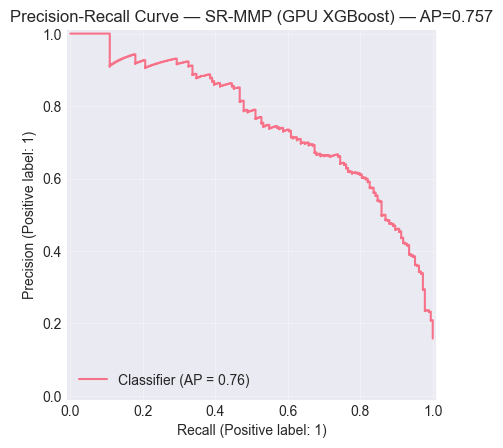

In [122]:
print("="*80)
print("5. PR CURVE (GPU XGBOOST)")
print("="*80)

import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from xgboost import XGBClassifier

# اختيار أفضل endpoint
example_target = results_df.loc[0, "target"]
print(f"Plotting PR curve for: {example_target}")

# =========================
# Prepare data
# =========================
y = df_feat[example_target]
mask = y.notna()

X = X_model[mask.values]
y = y[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# =========================
# GPU XGBoost model
# =========================
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1

model = XGBClassifier(
    objective="binary:logistic",

    # GPU
    tree_method="hist",
    device="cuda",

    # same config as training
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

# =========================
# Precision-Recall curve
# =========================
y_score = model.predict_proba(X_test)[:, 1]

ap = average_precision_score(y_test, y_score)
PrecisionRecallDisplay.from_predictions(y_test, y_score)

plt.title(f"Precision-Recall Curve — {example_target} (GPU XGBoost) — AP={ap:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

In [124]:
print("="*80)
print("6. 5-MODEL COMPARISON (OPTIMIZED GPU VERSION)")
print("="*80)

import shutil
import subprocess
import numpy as np

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

# =========================
# SPEED SETTINGS
# =========================
FAST_MODE = False
N_SPLITS = 3 if FAST_MODE else 5
N_ITER = 8 if FAST_MODE else 20

print(f"FAST_MODE={FAST_MODE} | CV folds={N_SPLITS} | n_iter={N_ITER}")

# =========================
# GPU DETECTION
# =========================
has_gpu = shutil.which("nvidia-smi") is not None
use_gpu = False

if has_gpu:
    try:
        out = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True)
        use_gpu = "GPU" in out.stdout
    except:
        use_gpu = False

print("GPU detected:", use_gpu)

# =========================
# DATA (PRIMARY ENDPOINT)
# =========================
mask = df_feat[primary_target].notna().values
X_primary = X_model[mask]
y_primary = df_feat.loc[mask, primary_target].astype(int).values

print(f"Endpoint: {primary_target}")
print(f"Shape: {X_primary.shape}")
print(f"Pos rate: {y_primary.mean()*100:.2f}%")

import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",

        # GPU (if available)
        "tree_method": "hist" if use_gpu else "auto",
    }

    # search space
    params.update({
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "min_child_weight": trial.suggest_categorical("min_child_weight", [5, 10, 20]),
        "random_state": 42,
        "n_jobs": -1,
    })

    # compute scale_pos_weight from y_primary (non-missing)
    neg = (y_primary == 0).sum()
    pos = (y_primary == 1).sum()
    scale_pos_weight = float(neg) / float(pos) if pos > 0 else 1.0
    params["scale_pos_weight"] = scale_pos_weight

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_primary,
        y_primary,
        cv=cv,
        scoring="average_precision"
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best AP:", study.best_value)
print("Best params:", study.best_params)

6. 5-MODEL COMPARISON (OPTIMIZED GPU VERSION)
FAST_MODE=False | CV folds=5 | n_iter=20


[I 2026-05-21 14:08:17,829] A new study created in memory with name: no-name-03513973-bf08-43fd-b4d5-796a63338ac0


GPU detected: True
Endpoint: NR-AR
Shape: (7265, 2056)
Pos rate: 4.25%


[I 2026-05-21 14:08:34,934] Trial 0 finished with value: 0.5473586533495437 and parameters: {'max_depth': 6, 'learning_rate': 0.02682556965214846, 'n_estimators': 230, 'subsample': 0.7685906477321726, 'colsample_bytree': 0.4556554981153232, 'reg_lambda': 3.2089931367217805, 'min_child_weight': 10}. Best is trial 0 with value: 0.5473586533495437.
[I 2026-05-21 14:09:21,969] Trial 1 finished with value: 0.5354906212731417 and parameters: {'max_depth': 6, 'learning_rate': 0.05550895344133794, 'n_estimators': 662, 'subsample': 0.9205896123211652, 'colsample_bytree': 0.3623719748619753, 'reg_lambda': 2.5021166923881624, 'min_child_weight': 20}. Best is trial 0 with value: 0.5473586533495437.
[I 2026-05-21 14:09:48,419] Trial 2 finished with value: 0.5227569744205625 and parameters: {'max_depth': 4, 'learning_rate': 0.12042557217924929, 'n_estimators': 450, 'subsample': 0.6065153232744825, 'colsample_bytree': 0.3654136379441182, 'reg_lambda': 3.189702676065111, 'min_child_weight': 20}. Best 

KeyboardInterrupt: 

In [ ]:
import optuna
import joblib
import os
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

os.makedirs("models", exist_ok=True)

results_optuna = []

def optuna_objective(trial, X, y):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",

        # GPU
        "tree_method": "hist",
        "device": "cuda",

        # search space
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),

        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    score = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]

        score.append(roc_auc_score(y_val, preds))

    return np.mean(score)


for target in target_columns:

    print(f"\n🚀 Optimizing: {target}")

    y = df_feat[target]
    mask = y.notna()

    X = X_model[mask.values]
    y = y[mask].astype(int).values

    if len(np.unique(y)) < 2:
        print("Skipping (only one class)")
        continue

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: optuna_objective(trial, X, y), n_trials=15)

    print("Best AUC:", study.best_value)

    # Train final model
    best_params = study.best_params

    best_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        **best_params
    )

    best_model.fit(X, y)

    # Save model
    joblib.dump(best_model, f"models/{target}_xgb.pkl")

    results_optuna.append({
        "target": target,
        "optuna_auc": study.best_value
    })


results_optuna_df = pd.DataFrame(results_optuna)
display(results_optuna_df)

[I 2026-05-21 01:58:08,648] A new study created in memory with name: no-name-470a4400-2e0f-413a-87a5-617a5c4bc2fd



🚀 Optimizing: NR-AR


[I 2026-05-21 01:58:22,824] Trial 0 finished with value: 0.8064679658120962 and parameters: {'max_depth': 5, 'learning_rate': 0.11335319949020072, 'n_estimators': 458, 'subsample': 0.6682300349240442, 'colsample_bytree': 0.901885323620545, 'reg_lambda': 2.9999448080536815}. Best is trial 0 with value: 0.8064679658120962.
[I 2026-05-21 01:58:31,578] Trial 1 finished with value: 0.8135165831456955 and parameters: {'max_depth': 4, 'learning_rate': 0.10852851632349023, 'n_estimators': 379, 'subsample': 0.7630212371053559, 'colsample_bytree': 0.8388794133889506, 'reg_lambda': 2.82695969960995}. Best is trial 1 with value: 0.8135165831456955.
[I 2026-05-21 01:58:40,059] Trial 2 finished with value: 0.8146802107962188 and parameters: {'max_depth': 3, 'learning_rate': 0.15475653041753473, 'n_estimators': 531, 'subsample': 0.9447586530427086, 'colsample_bytree': 0.852072712973192, 'reg_lambda': 4.050707084153988}. Best is trial 2 with value: 0.8146802107962188.
[I 2026-05-21 01:58:53,418] Trial

Best AUC: 0.8279916773102709


[I 2026-05-21 02:01:40,752] A new study created in memory with name: no-name-9e1c8d1d-535f-4db5-b8a8-53aa08df10ed


...

[I 2026-05-21 02:38:36,125] A new study created in memory with name: no-name-70cea859-6d83-4c64-b706-1d82d905f6b9



🚀 Optimizing: SR-p53


[I 2026-05-21 02:38:54,882] Trial 0 finished with value: 0.8512095598950743 and parameters: {'max_depth': 7, 'learning_rate': 0.12111910502615614, 'n_estimators': 397, 'subsample': 0.6066545365454511, 'colsample_bytree': 0.9543726335266094, 'reg_lambda': 3.1729639229369324}. Best is trial 0 with value: 0.8512095598950743.
[I 2026-05-21 02:39:03,381] Trial 1 finished with value: 0.8471838354600996 and parameters: {'max_depth': 6, 'learning_rate': 0.1801503084431963, 'n_estimators': 259, 'subsample': 0.638240389486823, 'colsample_bytree': 0.6260377139067769, 'reg_lambda': 3.113758260899817}. Best is trial 0 with value: 0.8512095598950743.
[I 2026-05-21 02:39:14,651] Trial 2 finished with value: 0.8594240478128757 and parameters: {'max_depth': 7, 'learning_rate': 0.026494204093613208, 'n_estimators': 297, 'subsample': 0.6805353983193805, 'colsample_bytree': 0.6654764683596963, 'reg_lambda': 1.6689578839237655}. Best is trial 2 with value: 0.8594240478128757.
[I 2026-05-21 02:39:32,190] Tr

Best AUC: 0.867005363537992


,target,optuna_auc
0,NR-AR,0.827992
1,NR-AR-LBD,0.863268
2,NR-AhR,0.900694
3,NR-Aromatase,0.864119
4,NR-ER,0.741614
5,NR-ER-LBD,0.822640
6,NR-PPAR-gamma,0.823890
7,SR-ARE,0.829087
8,SR-ATAD5,0.863148
9,SR-HSE,0.792361


In [ ]:
comparison = []

for target in target_columns:

    # -------------------
    # baseline (your old results)
    # -------------------
    baseline_row = results_df[results_df["target"] == target]

    baseline_auc = float(baseline_row["roc_auc"].values[0]) if len(baseline_row) else None

    # -------------------
    # optuna result
    # -------------------
    optuna_row = results_optuna_df[results_optuna_df["target"] == target]

    optuna_auc = float(optuna_row["optuna_auc"].values[0]) if len(optuna_row) else None

    if baseline_auc and optuna_auc:
        comparison.append({
            "target": target,
            "baseline_auc": baseline_auc,
            "optuna_auc": optuna_auc,
            "improvement": optuna_auc - baseline_auc
        })

comparison_df = pd.DataFrame(comparison).sort_values("improvement", ascending=False)

display(comparison_df)

print("\n📊 Average improvement:",
      comparison_df["improvement"].mean())

,target,baseline_auc,optuna_auc,improvement
1,NR-AR-LBD,0.785375,0.863268,0.077893
0,NR-AR,0.756835,0.827992,0.071156
4,NR-ER,0.687218,0.741614,0.054397
5,NR-ER-LBD,0.801146,0.822640,0.021494
2,NR-AhR,0.895660,0.900694,0.005034
3,NR-Aromatase,0.869985,0.864119,-0.005866
9,SR-HSE,0.798278,0.792361,-0.005917
10,SR-MMP,0.930148,0.920772,-0.009376
7,SR-ARE,0.841012,0.829087,-0.011925
8,SR-ATAD5,0.876375,0.863148,-0.013227



📊 Average improvement: 0.01228257308490289


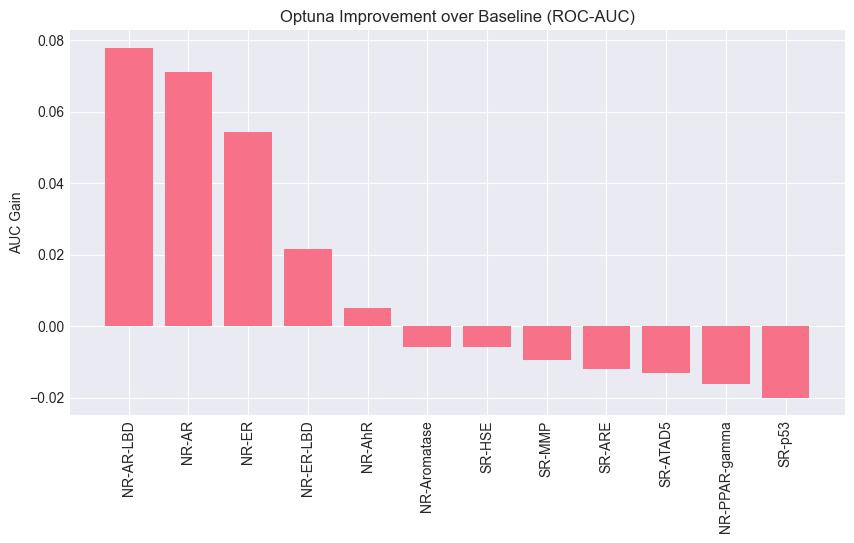

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(comparison_df["target"], comparison_df["improvement"])

plt.xticks(rotation=90)
plt.title("Optuna Improvement over Baseline (ROC-AUC)")
plt.ylabel("AUC Gain")
plt.show()

<Figure size 1000x600 with 0 Axes>

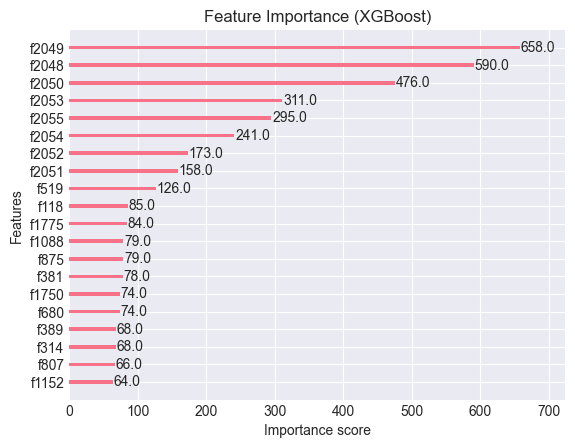

In [ ]:
best_model = XGBClassifier(**study.best_params)
best_model.fit(X_primary, y_primary)

import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,6))
plot_importance(best_model, max_num_features=20)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [ ]:
import optuna
import joblib
import os
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

os.makedirs("models", exist_ok=True)

results_optuna = []


def optuna_objective(trial, X, y):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",

        # GPU
        "tree_method": "hist" if use_gpu else "auto",

        # search space
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.7),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "min_child_weight": trial.suggest_categorical("min_child_weight", [5, 10, 20]),

        "random_state": 42,
        "n_jobs": -1
    }

    # compute scale_pos_weight from provided y
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    scale_pos_weight = float(neg) / float(pos) if pos > 0 else 1.0
    params["scale_pos_weight"] = scale_pos_weight

    model = XGBClassifier(**params)

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    score = []

    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train)
        preds = model.predict_proba(X_val)[:, 1]

        score.append(average_precision_score(y_val, preds))

    return np.mean(score)


for target in target_columns:

    print(f"\n🚀 Optimizing: {target}")

    y = df_feat[target]
    mask = y.notna()

    X = X_model[mask.values]
    y = y[mask].astype(int).values

    if len(np.unique(y)) < 2:
        print("Skipping (only one class)")
        continue

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: optuna_objective(trial, X, y), n_trials=15)

    print("Best AP:", study.best_value)

    # Train final model
    best_params = study.best_params
    # ensure eval_metric and tree_method are set appropriately
    best_params.update({"objective": "binary:logistic", "eval_metric": "aucpr", "tree_method": "hist" if use_gpu else "auto", "random_state": 42, "n_jobs": -1})

    # compute final scale_pos_weight and inject
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    scale_pos_weight = float(neg) / float(pos) if pos > 0 else 1.0
    best_params["scale_pos_weight"] = scale_pos_weight

    best_model = XGBClassifier(**best_params)
    best_model.fit(X, y)

    # Save model
    joblib.dump(best_model, f"models/{target}_xgb.pkl")

    results_optuna.append({
        "target": target,
        "optuna_ap": study.best_value
    })


results_optuna_df = pd.DataFrame(results_optuna)
display(results_optuna_df)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

def plot_curves(model, X_test, y_test):

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[0])
    ax[0].set_title("ROC Curve")

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
    ax[1].set_title("Precision-Recall Curve")

    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(y_test, pred):

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_distribution(y, title="Class Distribution"):

    sns.countplot(x=y)
    plt.title(title)
    plt.show()

    pos_rate = y.mean()
    print(f"Positive rate: {pos_rate:.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold

def plot_learning_curve(model, X, y, title="Learning Curve"):

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Train AUC")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="CV AUC")

    plt.title(title)
    plt.xlabel("Training Size")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
import joblib

target = primary_target

model = joblib.load(f"models/{target}_xgb.pkl")

In [ ]:
from sklearn.model_selection import train_test_split

y = df_feat[target]
mask = y.notna()

X = X_model[mask.values]
y = y[mask].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
results, pred, proba = evaluate_model(model, X_test, y_test)

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1391
           1       0.89      0.39      0.54        62

    accuracy                           0.97      1453
   macro avg       0.93      0.69      0.76      1453
weighted avg       0.97      0.97      0.97      1453


📌 Metrics Summary:
ROC-AUC: 0.9535
Accuracy: 0.9718
Precision: 0.8889
Recall: 0.3871
F1-score: 0.5393


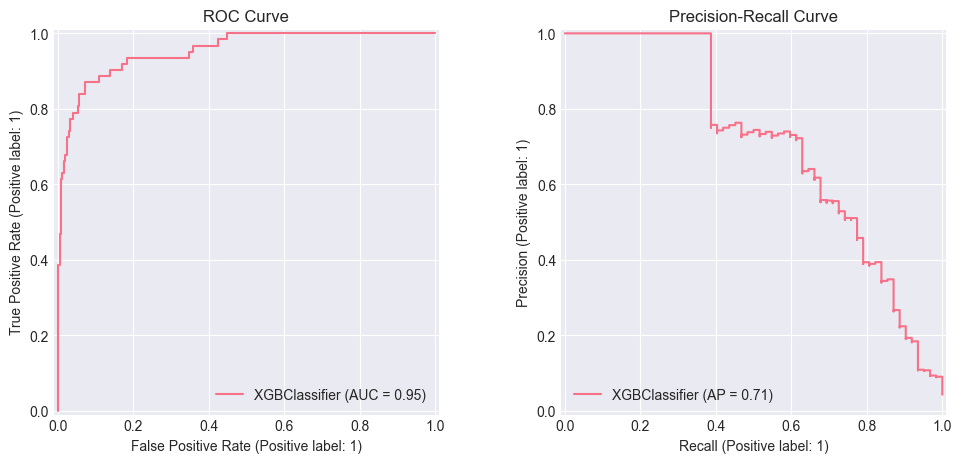

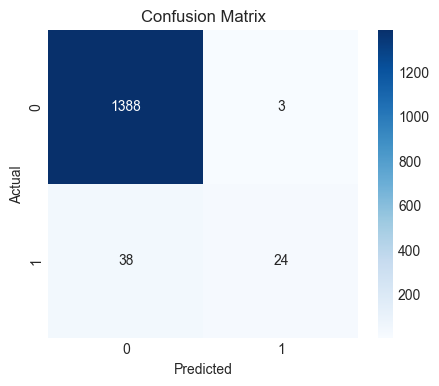

<Figure size 1000x600 with 0 Axes>

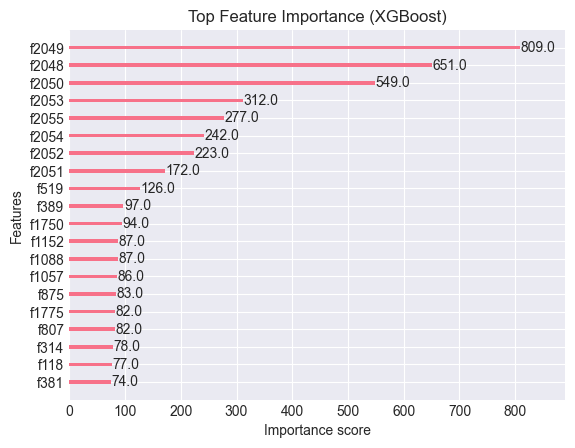

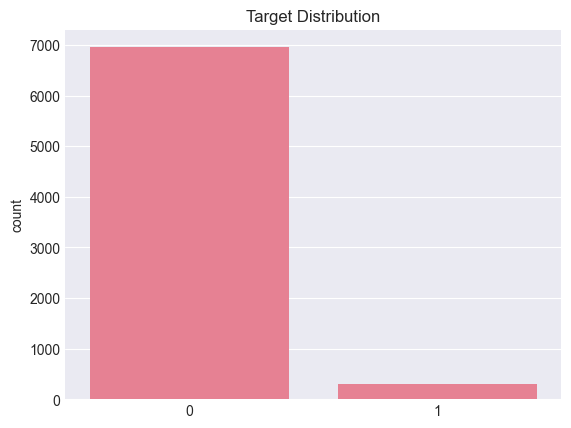

Positive rate: 0.0425


In [ ]:

plot_curves(model, X_test, y_test)
plot_conf_matrix(y_test, pred)
import matplotlib.pyplot as plt
from xgboost import plot_importance

def plot_feature_importance(model):

    plt.figure(figsize=(10,6))
    plot_importance(model, max_num_features=20)
    plt.title("Top Feature Importance (XGBoost)")
    plt.show()
plot_feature_importance(model)
plot_class_distribution(y, "Target Distribution")

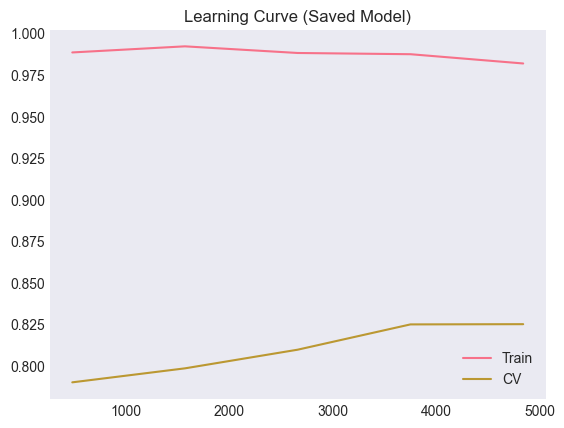

In [ ]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), label="CV")

plt.title("Learning Curve (Saved Model)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

y = df_feat[target]
mask = y.notna()

X = X_model[mask.values]
y = y[mask].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("📊 RESULTS FOR:", target)

print("\nROC-AUC:", roc_auc_score(y_test, proba))
print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, zero_division=0))
print("Recall:", recall_score(y_test, pred, zero_division=0))
print("F1:", f1_score(y_test, pred, zero_division=0))

print("\n📌 Classification Report:\n")
print(classification_report(y_test, pred))

📊 RESULTS FOR: NR-AR

ROC-AUC: 0.9534565524918253
Accuracy: 0.9717825189263593
Precision: 0.8888888888888888
Recall: 0.3870967741935484
F1: 0.5393258426966292

📌 Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1391
           1       0.89      0.39      0.54        62

    accuracy                           0.97      1453
   macro avg       0.93      0.69      0.76      1453
weighted avg       0.97      0.97      0.97      1453



## Multi-Task Learning Prototype (PyTorch)

This section trains a lightweight shared MLP for all toxicity endpoints simultaneously.

- Input: `X_model` (fingerprints + descriptors)
- Targets: all `target_columns`
- Missing labels: handled via a masked loss (only observed labels contribute)
- Metric: per-task and macro **Average Precision (PR-AUC)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
except Exception as e:
    raise ImportError("PyTorch is required for the MTL prototype. Install with: pip install torch") from e

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device
mtl_device = "cuda" if torch.cuda.is_available() else "cpu"
print("MTL device:", mtl_device)

# Prepare multi-task matrices
X_mtl = X_model.astype(np.float32)
Y_raw = df_feat[target_columns].to_numpy(dtype=np.float32)
M_raw = (~np.isnan(Y_raw)).astype(np.float32)  # label-observed mask
Y_filled = np.nan_to_num(Y_raw, nan=0.0).astype(np.float32)

# Stratify by "any observed toxic label" for a balanced split
Y_obs = np.where(M_raw > 0, Y_filled, 0.0)
y_any_toxic = (Y_obs.max(axis=1) > 0).astype(int)

idx = np.arange(X_mtl.shape[0])
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=y_any_toxic,
)

X_train_np = X_mtl[idx_train]
X_test_np = X_mtl[idx_test]
Y_train_np = Y_filled[idx_train]
Y_test_np = Y_filled[idx_test]
M_train_np = M_raw[idx_train]
M_test_np = M_raw[idx_test]

# Scale numeric ranges for stable NN optimization
scaler_mtl = StandardScaler()
X_train_np = scaler_mtl.fit_transform(X_train_np).astype(np.float32)
X_test_np = scaler_mtl.transform(X_test_np).astype(np.float32)

n_features = X_train_np.shape[1]
n_tasks = Y_train_np.shape[1]
print(f"MTL train shape: {X_train_np.shape}, tasks: {n_tasks}")

In [ ]:
class MultiTaskMLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim),
        )

    def forward(self, x):
        return self.net(x)


def masked_bce_with_logits(logits, targets, mask, pos_weight):
    # loss per sample/task, then mask missing labels
    bce = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pos_weight)
    loss_mat = bce(logits, targets)
    return (loss_mat * mask).sum() / mask.sum().clamp_min(1.0)


# Compute per-task class weights on observed labels only
pos_counts = (Y_train_np * M_train_np).sum(axis=0)
neg_counts = ((1.0 - Y_train_np) * M_train_np).sum(axis=0)
pos_weight_np = np.where(pos_counts > 0, neg_counts / np.clip(pos_counts, 1e-6, None), 1.0).astype(np.float32)

X_train_t = torch.from_numpy(X_train_np)
Y_train_t = torch.from_numpy(Y_train_np)
M_train_t = torch.from_numpy(M_train_np)

X_test_t = torch.from_numpy(X_test_np).to(mtl_device)

train_ds = TensorDataset(X_train_t, Y_train_t, M_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

mtl_model = MultiTaskMLP(n_features, n_tasks).to(mtl_device)
optimizer = torch.optim.AdamW(mtl_model.parameters(), lr=1e-3, weight_decay=1e-4)
pos_weight_t = torch.from_numpy(pos_weight_np).to(mtl_device)

# Lightweight training settings
EPOCHS = 12
PATIENCE = 3
best_state = None
best_loss = np.inf
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    mtl_model.train()
    epoch_losses = []

    for xb, yb, mb in train_loader:
        xb = xb.to(mtl_device)
        yb = yb.to(mtl_device)
        mb = mb.to(mtl_device)

        optimizer.zero_grad()
        logits = mtl_model(xb)
        loss = masked_bce_with_logits(logits, yb, mb, pos_weight_t)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    mean_loss = float(np.mean(epoch_losses))
    print(f"Epoch {epoch:02d} | train_loss={mean_loss:.4f}")

    if mean_loss < best_loss:
        best_loss = mean_loss
        best_state = {k: v.detach().cpu().clone() for k, v in mtl_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    mtl_model.load_state_dict(best_state)

print(f"Best train loss: {best_loss:.4f}")

In [ ]:
# Evaluate MTL model on test split (ignore missing labels per endpoint)
mtl_model.eval()
with torch.no_grad():
    logits_test = mtl_model(X_test_t)
    proba_test = torch.sigmoid(logits_test).cpu().numpy()

rows = []
for j, target in enumerate(target_columns):
    valid = M_test_np[:, j] > 0
    if valid.sum() < 20:
        continue

    y_true_j = Y_test_np[valid, j].astype(int)
    y_prob_j = proba_test[valid, j]

    if len(np.unique(y_true_j)) < 2:
        continue

    ap_j = average_precision_score(y_true_j, y_prob_j)
    rows.append({"target": target, "mtl_ap": float(ap_j), "n_valid": int(valid.sum())})

mtl_results_df = pd.DataFrame(rows).sort_values("mtl_ap", ascending=False)
display(mtl_results_df)

if len(mtl_results_df):
    print(f"MTL Macro AP (mean across endpoints): {mtl_results_df['mtl_ap'].mean():.4f}")
else:
    print("No evaluable endpoints found in test split.")

## Molecule-Level Inference

Use trained endpoint models to score custom SMILES and inspect per-endpoint toxicity probabilities.

In [ ]:
import joblib
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

In [ ]:
smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"   # Aspirin

In [ ]:
mol = Chem.MolFromSmiles(smiles)

if mol is None:
    raise ValueError("Invalid SMILES!")

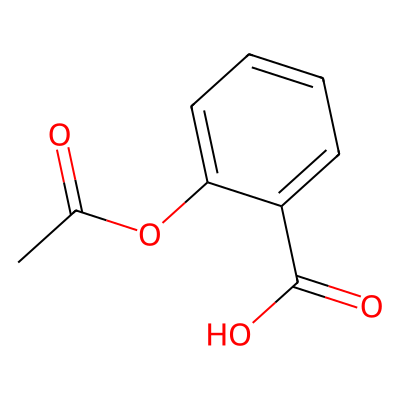

In [ ]:
img = Draw.MolToImage(mol, size=(400,400))
display(img)

In [ ]:
fp_gen = GetMorganGenerator(radius=2, fpSize=2048)

fp = fp_gen.GetFingerprint(mol)

fp_array = np.array(fp)

In [ ]:
desc = np.array([
    Descriptors.MolWt(mol),
    Descriptors.MolLogP(mol),
    Descriptors.TPSA(mol),
    Descriptors.NumHDonors(mol),
    Descriptors.NumHAcceptors(mol),
    Descriptors.NumRotatableBonds(mol),
    Descriptors.RingCount(mol),
    Descriptors.HeavyAtomCount(mol),
])

In [ ]:
X_new = np.concatenate([fp_array, desc]).reshape(1, -1)

X_new = X_new.astype(np.float32)

In [ ]:
proba = model.predict_proba(X_new)[0,1]
pred = model.predict(X_new)[0]

print("🧪 Molecule:", smiles)

print(f"\n📊 Toxicity probability ({target}): {proba:.4f}")

print("Prediction:",
      "☠️ Toxic" if pred == 1 else "✅ Non-toxic")

🧪 Molecule: CC(=O)OC1=CC=CC=C1C(=O)O

📊 Toxicity probability (NR-AR): 0.0399
Prediction: ✅ Non-toxic


In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from torch import threshold


def predict_molecules(smiles_list, target_columns, model_dir="models"):
    """
    Predict toxicity for a list of molecules using saved XGBoost .pkl models.
    
    Parameters
    ----------
    smiles_list : list
        List of SMILES strings
        
    target_columns : list
        Toxicity endpoint names
        
    model_dir : str
        Folder containing saved .pkl models
    """

    # Morgan fingerprint generator
    fp_gen = GetMorganGenerator(radius=2, fpSize=2048)

    for smiles in smiles_list:

        print("="*80)
        print("🧪 MOLECULE:", smiles)
        print("="*80)

        # Parse molecule
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            print("❌ Invalid SMILES")
            continue

        # Draw molecule
        img = Draw.MolToImage(mol, size=(300,300))
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # Fingerprint
        fp = fp_gen.GetFingerprint(mol)
        fp_array = np.array(fp)

        # RDKit descriptors
        desc = np.array([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.RingCount(mol),
            Descriptors.HeavyAtomCount(mol),
        ])

        # Final feature vector
        X_new = np.concatenate([fp_array, desc]).reshape(1, -1)
        X_new = X_new.astype(np.float32)

        results = []

        # Predict for all endpoints
        for target in target_columns:

            try:
                model = joblib.load(f"{model_dir}/{target}_xgb.pkl")

                threshold = 0.05
                proba = model.predict_proba(X_new)[0,1]
                pred = int(proba >= threshold)

                results.append({
                    "Endpoint": target,
                    "Probability": round(float(proba), 4),
                    "Prediction": "☠️ Toxic" if pred == 1 else "✅ Non-toxic"
                })

            except Exception as e:
                results.append({
                    "Endpoint": target,
                    "Probability": None,
                    "Prediction": f"❌ Error: {e}"
                })

        # Display results
        results_df = pd.DataFrame(results)

        display(results_df.sort_values("Probability", ascending=False))

🧪 MOLECULE: C=O


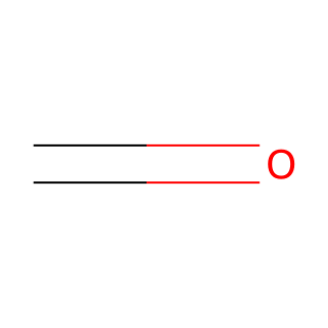

,Endpoint,Probability,Prediction
7,SR-ARE,0.0888,☠️ Toxic
4,NR-ER,0.0499,✅ Non-toxic
2,NR-AhR,0.0274,✅ Non-toxic
9,SR-HSE,0.0207,✅ Non-toxic
10,SR-MMP,0.0176,✅ Non-toxic
5,NR-ER-LBD,0.0127,✅ Non-toxic
3,NR-Aromatase,0.0096,✅ Non-toxic
6,NR-PPAR-gamma,0.0092,✅ Non-toxic
8,SR-ATAD5,0.0075,✅ Non-toxic
11,SR-p53,0.0060,✅ Non-toxic


In [ ]:
molecules = [
    "C=O"         # Caffeine
]

predict_molecules(molecules, target_columns)